In [ ]:
import sys, os
# Fix paths so kit.py and data/ are always found from project root
ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

In [24]:
import numpy as np 
import pandas as pd
import kit as erk

In [25]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
erk.bond_price(5, 100, .05, 12, .03)

0    109.275393
dtype: float64

In [27]:
rates, zc_prices = erk.cir(10, 500, b=0.03, r_0=0.03)

In [28]:
erk.bond_price(5, 100, .05, 12, rates.iloc[0][[1, 2, 3]])

1    109.275393
2    109.275393
3    109.275393
dtype: float64

In [29]:
erk.bond_price(5, 100, .05, 12, rates.iloc[1][[1, 2, 3]])

1    109.237193
2    110.592162
3    108.911119
dtype: float64

In [30]:
rates[[1, 2, 3]].head()

,1,2,3
0,0.030000,0.030000,0.030000
1,0.030079,0.027312,0.030750
2,0.026974,0.023772,0.028569
3,0.028757,0.023729,0.024228
4,0.028519,0.029522,0.023770


<Axes: >

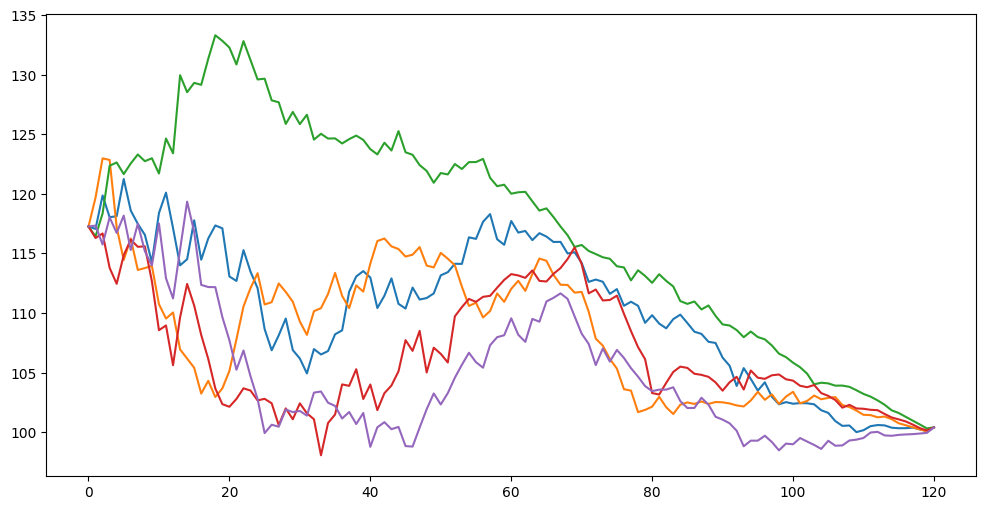

In [31]:
erk.bond_price(10, 100, .05, 12, rates[[1, 2, 3, 4, 5]]).plot(legend=False, figsize=(12, 6))

In [32]:
prices = erk.bond_price(10, 100, .05, 12, rates[[1, 2, 3, 4, 5]])
prices

,1,2,3,4,5
0,117.260292,117.260292,117.260292,117.260292,117.260292
1,117.063159,119.689777,116.435794,116.29885,117.34003
2,119.86871,122.977921,118.353204,116.67774,115.754438
3,118.042515,122.846647,122.360233,113.796573,118.03085
4,118.129607,117.203315,122.633651,112.458059,116.724238
...,...,...,...,...,...
116,100.349373,100.593076,101.297812,100.913003,99.823239
117,100.393502,100.422603,100.976763,100.648084,99.849713
118,100.244314,100.244841,100.658721,100.352344,99.898264
119,100.10328,100.095146,100.326159,100.158389,99.956178


In [35]:
br = prices.pct_change().dropna()
erk.annual_return(br, 12)

/var/folders/d3/4j2xrjxn06v329lnxwrwmzs80000gn/T/ipykernel_20760/2619332714.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  br = prices.pct_change().dropna()


1   -0.015387
2   -0.015387
3   -0.015387
4   -0.015387
5   -0.015387
dtype: float64

In [37]:
p = erk.bond_price(10, 100, .05, 12, rates[[1, 2, 3, 4]])
p

,1,2,3,4
0,117.260292,117.260292,117.260292,117.260292
1,117.063159,119.689777,116.435794,116.29885
2,119.86871,122.977921,118.353204,116.67774
3,118.042515,122.846647,122.360233,113.796573
4,118.129607,117.203315,122.633651,112.458059
...,...,...,...,...
116,100.349373,100.593076,101.297812,100.913003
117,100.393502,100.422603,100.976763,100.648084
118,100.244314,100.244841,100.658721,100.352344
119,100.10328,100.095146,100.326159,100.158389


In [38]:
btr= erk.bond_total_return(p, 100, .05, 12)
erk.annual_return(btr, 12)

<string>:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.


1    0.030376
2    0.031242
3    0.027753
4    0.031927
dtype: object

In [39]:
# Assume a 10 year bond
price_10 = erk.bond_price(10, 100, .05, 12, rates)
price_10[[1,2 , 3]].tail()

,1,2,3
116,100.349373,100.593076,101.297812
117,100.393502,100.422603,100.976763
118,100.244314,100.244841,100.658721
119,100.10328,100.095146,100.326159
120,100.416667,100.416667,100.416667


In [40]:
price_30 = erk.bond_price(30, 100, .05, 12, rates)
price_30[[1,2 , 3]].tail()

,1,2,3
116,114.763073,126.725193,171.087446
117,123.112533,125.079197,171.123025
118,121.22498,121.276738,171.949756
119,117.512663,115.996638,170.681592
120,113.536794,111.752351,174.146898


In [42]:
rets_30 = erk.bond_total_return(price_30, 100, .05, 12)
rets_10 = erk.bond_total_return(price_10, 100, .05, 12)


rets_bonds = .6*rets_10 + .4*rets_30

<string>:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<str

In [43]:
rets_bonds

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
1,0.046062,0.001566,0.03528,-0.006363,-0.008088,0.005081,-0.024717,0.017855,0.030507,-0.020421,...,-0.023749,-0.017013,0.017991,0.058978,0.037833,0.036753,0.057782,0.010859,-0.013174,-0.021246
2,0.008287,0.040357,0.046126,0.028846,0.008938,-0.015969,0.034788,-0.018384,0.003468,-0.059431,...,0.003555,0.00286,-0.029843,0.034657,0.008906,0.005663,0.0115,0.027637,0.00173,0.014731
3,0.02445,-0.018742,0.002499,0.056056,-0.032367,0.033757,-0.030671,-0.032596,0.017208,-0.000144,...,0.063886,0.102296,-0.01883,-0.022987,-0.013566,0.000286,0.022776,0.032288,-0.008872,0.02519
4,-0.00002,0.00522,-0.064398,0.007563,-0.01329,-0.012495,0.087068,0.011077,0.034332,0.024105,...,-0.014707,-0.031929,0.027309,0.058283,-0.012048,-0.026177,0.009525,0.023681,-0.015523,-0.03633
5,0.028248,0.044718,-0.030833,-0.008012,0.036152,0.022986,0.004661,-0.003271,0.000418,-0.023204,...,0.002947,0.067208,-0.036226,-0.047382,0.017985,0.01133,0.06812,0.004603,0.031667,0.029415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,0.004971,0.015957,-0.000191,0.001028,0.009734,0.003738,-0.00995,0.014179,0.031729,0.003463,...,0.003007,-0.005163,-0.006995,0.021878,-0.004107,-0.01048,0.018478,-0.005158,0.010137,0.015688
117,0.011689,0.033309,-0.002412,0.001624,-0.006661,0.00103,-0.014454,-0.001334,-0.026792,-0.014713,...,0.01578,0.036692,0.004744,0.008126,-0.009093,0.014662,-0.001096,0.001423,0.004475,0.005388
118,-0.011062,-0.00318,-0.0094,0.003492,-0.024323,0.004272,-0.010718,0.000737,0.020731,0.004146,...,0.003829,0.000936,-0.027219,0.008709,-0.007445,0.010516,0.000887,-0.002173,0.005243,0.003659
119,0.015955,-0.009225,-0.014443,-0.001479,-0.009357,0.009017,0.009742,-0.000419,0.005762,0.004882,...,0.000868,0.013509,0.022543,0.006369,0.043211,0.013822,-0.013676,-0.006993,-0.009615,-0.001738


In [47]:
mean_ret_bonds = rets_bonds.mean(axis="columns")
erk.summary_stats(pd.DataFrame(mean_ret_bonds))

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Kurtosis,Skew,Sharp Ratio,CVaR 5% (Gaussian),Historic CVaR 5%
0,0.035726,0.003352,1.662709,0.0,2.87231,0.071713,1.662709,-0.001362,-0.000946


In [51]:
prices_eq = erk.gbm(10, 500, mu=0.07, sigma=0.15)
prices_eq.shape

(121, 500)

In [54]:
rets_eq = prices_eq.pct_change().dropna()
rets_eq.shape

(120, 500)

In [55]:
rets_bonds.shape

(120, 500)

In [56]:
rets = .7 * rets_eq + .3 * rets_bonds
rets_mean = rets.mean(axis='columns')
erk.summary_stats(pd.DataFrame(rets_mean))

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Kurtosis,Skew,Sharp Ratio,CVaR 5% (Gaussian),Historic CVaR 5%
0,0.061628,0.004415,6.971949,0.0,2.851902,0.102746,6.971949,-0.002943,-0.002423
